<a href="https://colab.research.google.com/github/Faraz-hue/DecodeLabs-Task-1-Faraz/blob/main/DecodeLabs-Task-1-Faraz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task 1: Data Understanding


In [ ]:
import pandas as pd
import numpy as np

load a dataset

In [ ]:
df=pd.read_csv("data_science_job.csv")

In [ ]:
df.head(5)


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer in office,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician (Remote),ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst in office,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S


In [ ]:
df.columns

Index(['work_year', 'job_title', 'job_category', 'salary_currency', 'salary',
       'salary_in_usd', 'employee_residence', 'experience_level',
       'employment_type', 'work_setting', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
df.tail()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
4995,2020,Machine Learning Engineer (Remote),NaN,NaN,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer (Remote),NaN,NaN,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S
4999,2020,Data Scientist (Remote),Engineering,GBP,143565,172425,CN,EX,CT,Remote,CN,L


Identify columns
 and
data types

In [ ]:

# Task 1: Dataset Overview
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Columns and Data Types:")
print(df.dtypes)
print("\nFirst 3 rows:")
print(df.head(3))

Dataset Shape: 5000 rows, 12 columns

Columns and Data Types:
work_year              int64
job_title             object
job_category          object
salary_currency       object
salary                 int64
salary_in_usd          int64
employee_residence    object
experience_level      object
employment_type       object
work_setting          object
company_location      object
company_size          object
dtype: object

First 3 rows:
   work_year                             job_title job_category  \
0       2022  Machine Learning Engineer  in office     Analysis   
1       2020                Statistician  (Remote)        ML/AI   
2       2022           Machine Learning Engineer          ML/AI   

  salary_currency  salary  salary_in_usd employee_residence experience_level  \
0             EUR  186597         136086                 US               MI   
1             JPY  110630          67982                 JP               EX   
2             INR   61280         153309            

This dataset contains 5,000 rows and 12 columns detailing global employment trends in the data science and AI sectors.

Target/Key Metric: salary_in_usd normalizes global compensation for direct comparison.

Categorical Features: Includes roles (job_title), experience levels (experience_level: EN, MI, SE, EX), employment arrangements (work_setting: Remote, Hybrid, In-person), and geographical dimensions (employee_residence, company_location)

##Task 2: Data Preprocessing (Cleaning & Organizing)

In [ ]:

missing_values = df.isnull().sum()

duplicate_count = df.duplicated().sum()
df_cleaned = df.drop_duplicates()

text_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].str.strip()

print(f"Missing values per column:\n{missing_values[missing_values > 0]}")
print(f"Duplicates found and removed: {duplicate_count}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Missing values per column:
job_category        500
salary_currency     500
experience_level    500
company_size        500
dtype: int64
Duplicates found and removed: 0
Cleaned dataset shape: (5000, 12)


##Task 3: Exploratory Data Analysis (EDA)

In [ ]:
# Statistical summary of USD Salaries
salary_stats = df_cleaned['salary_in_usd'].describe()
print("Salary (USD) Statistics:")
print(salary_stats)

# Identify Outliers using IQR
Q1 = df_cleaned['salary_in_usd'].quantile(0.25)
Q3 = df_cleaned['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['salary_in_usd'] < lower_bound) | (df_cleaned['salary_in_usd'] > upper_bound)]
print(f"\nNumber of salary outliers: {outliers.shape[0]}")

# Trends: Average Salary by Experience Level and Work Setting
print("\nAverage Salary by Experience Level:")
print(df_cleaned.groupby('experience_level')['salary_in_usd'].mean().sort_values())

print("\nAverage Salary by Work Setting:")
print(df_cleaned.groupby('work_setting')['salary_in_usd'].mean().sort_values())

Salary (USD) Statistics:
count      5000.000000
mean     114076.995800
std       49113.807687
min       30016.000000
25%       71343.750000
50%      114167.000000
75%      156665.750000
max      199985.000000
Name: salary_in_usd, dtype: float64

Number of salary outliers: 0

Average Salary by Experience Level:
experience_level
SE    112980.065858
MI    113389.446043
EX    113394.849866
EN    115287.299552
Name: salary_in_usd, dtype: float64

Average Salary by Work Setting:
work_setting
Remote       113053.136952
Hybrid       113890.171412
In-person    115271.929433
Name: salary_in_usd, dtype: float64


##Task 4: Data Visualization

/tmp/ipykernel_7602/1863553790.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='experience_level', y='salary_in_usd', ax=axes[1], order=['EN', 'MI', 'SE', 'EX'], palette='Set2')


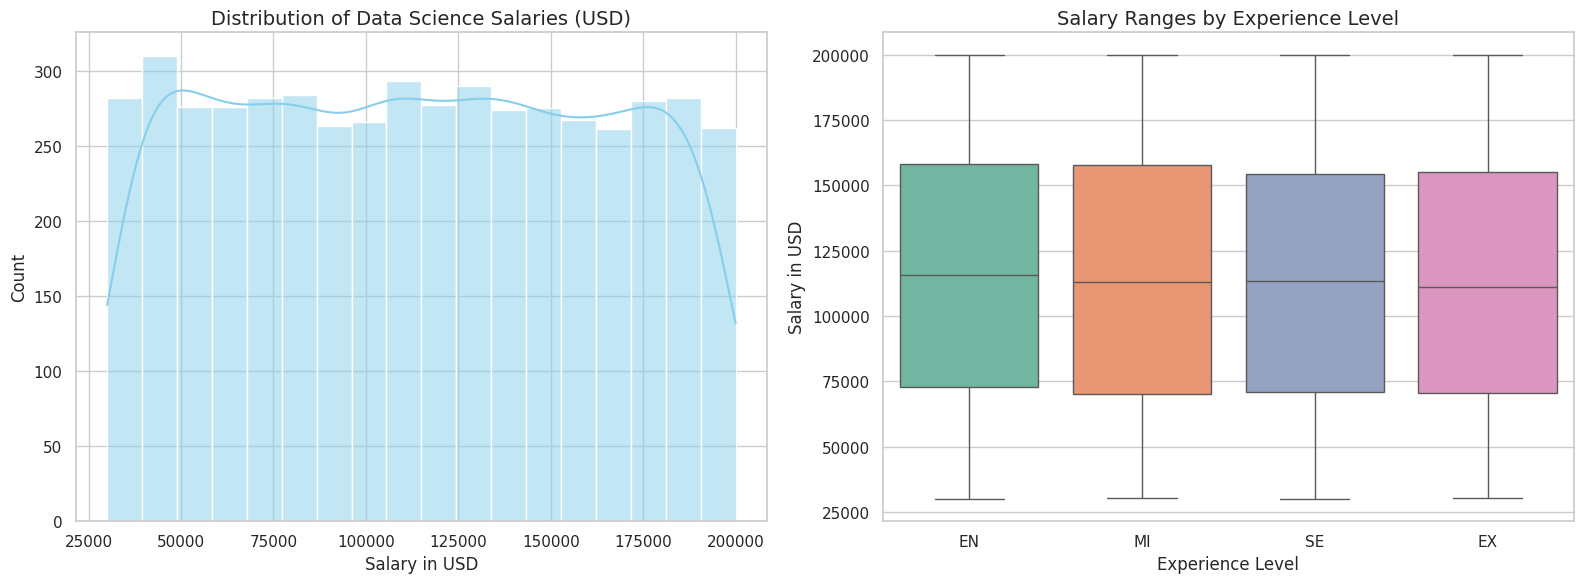

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Salary Distribution
sns.histplot(df_cleaned['salary_in_usd'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Data Science Salaries (USD)', fontsize=14)
axes[0].set_xlabel('Salary in USD')

# Chart 2: Salary by Experience Level Boxplot
sns.boxplot(data=df_cleaned, x='experience_level', y='salary_in_usd', ax=axes[1], order=['EN', 'MI', 'SE', 'EX'], palette='Set2')
axes[1].set_title('Salary Ranges by Experience Level', fontsize=14)
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Salary in USD')

plt.tight_layout()
plt.show()

In [ ]:
# Drop rows where critical features are missing before splitting your data
df_modeling = df_cleaned.dropna(subset=['experience_level', 'job_category', 'company_size'])

##Task 5: Predictive Modeling (Regression)

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df_model = df.copy()

df_model = df_model.drop_duplicates()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].str.strip()


# Reduce rare job titles
top_jobs = df_model['job_title'].value_counts().nlargest(5).index

df_model['job_title'] = df_model['job_title'].apply(
    lambda x: x if x in top_jobs else 'Other'
)

# Reduce rare countries
top_locations = df_model['company_location'].value_counts().nlargest(5).index

df_model['company_location'] = df_model['company_location'].apply(
    lambda x: x if x in top_locations else 'Other'
)

# -------------------------
# Feature Selection
# -------------------------

features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title',
    'job_category',
    'employee_residence',
    'work_setting',
    'company_location',
    'company_size'
]

target = 'salary_in_usd'

# Create feature matrix and target variable
X = df_model[features]
y = df_model[target]

print("Features Used:")
print(features)

# -------------------------
# Identify Column Types
# -------------------------

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# -------------------------
# Preprocessing Pipelines
# -------------------------

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_transformer, numeric_cols)
    ]
)

# -------------------------
# Train-Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# Build Model
# -------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

# -------------------------
# Create Full Pipeline
# -------------------------

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# -------------------------
# Train Model
# -------------------------

pipeline.fit(X_train, y_train)

# -------------------------
# Make Predictions
# -------------------------

y_pred = pipeline.predict(X_test)

# -------------------------
# Evaluate Model
# -------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("===================================")
print("Task 5: Predictive Modeling")
print("Random Forest Regressor")
print("===================================")

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

print(f"R-squared Score (R²): {r2:.4f}")


encoded_features = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get importance scores
importance_scores = pipeline.named_steps[
    'model'
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': importance_scores
})

# Sort importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 10 Important Features
print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# -------------------------
# Sample Predictions
# -------------------------

results = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

print("\nSample Predictions:")
print(results.head(10))

Features Used:
['work_year', 'experience_level', 'employment_type', 'job_title', 'job_category', 'employee_residence', 'work_setting', 'company_location', 'company_size']
Task 5: Predictive Modeling
Random Forest Regressor
Mean Absolute Error (MAE): $42,928.45
Root Mean Squared Error (RMSE): $50,080.76
R-squared Score (R²): -0.0713

Top 10 Important Features:
                           Feature  Importance
37                  num__work_year    0.074012
17         cat__job_category_ML/AI    0.030767
32     cat__company_location_Other    0.030036
15  cat__job_category_Data Science    0.029606
16   cat__job_category_Engineering    0.029604
14      cat__job_category_Analysis    0.029568
12            cat__job_title_Other    0.029507
2         cat__experience_level_MI    0.028923
25        cat__work_setting_Hybrid    0.028825
1         cat__experience_level_EX    0.028316

Sample Predictions:
   Actual Salary  Predicted Salary
0         125675      98818.484285
1          63435      95159.58

In [ ]:
df.columns

Index(['work_year', 'job_title', 'job_category', 'salary_currency', 'salary',
       'salary_in_usd', 'employee_residence', 'experience_level',
       'employment_type', 'work_setting', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
import seaborn as sns

In [ ]:
df_cleaned.columns.to_list()

['work_year',
 'job_title',
 'job_category',
 'salary_currency',
 'salary',
 'salary_in_usd',
 'employee_residence',
 'experience_level',
 'employment_type',
 'work_setting',
 'company_location',
 'company_size']

In [ ]:
renamelist=['WorkYear','JobTitle','JobCategory','SalaryCurremcy','Salary','SalaryinUsd','EmplResidence','ExpLevel','EmpType','WorkSetting','CompanyLocation','CompanySize']

In [ ]:
df_cleaned.columns=renamelist

In [ ]:
df_cleaned.dropna()

,WorkYear,JobTitle,JobCategory,SalaryCurremcy,Salary,SalaryinUsd,EmplResidence,ExpLevel,EmpType,WorkSetting,CompanyLocation,CompanySize
0,2022,Machine Learning Engineer in office,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician (Remote),ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst in office,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4993,2021,Data Scientist (Remote),Analysis,EUR,44674,100031,UK,MI,FT,Hybrid,UK,M
4994,2020,Statistician,Data Science,GBP,115923,40047,JP,SE,CT,In-person,CN,L
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


In [ ]:
df_cleaned.loc[:,"Salary"].notna().head()

,Salary
0,True
1,True
2,True
3,True
4,True
